In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                                  confusion_matrix,
                                  accuracy_score, f1_score)
from sklearn.pipeline import Pipeline

plt.style.use('ggplot')
print("All libraries loaded!")

All libraries loaded!


In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')

df = df.sample(50000, random_state=42).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (50000, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...


In [4]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


## Quick EDA


Missing values:
 Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
dtype: int64

Score distribution:
 Score
5    32097
4     7008
1     4528
3     3791
2     2576
Name: count, dtype: int64


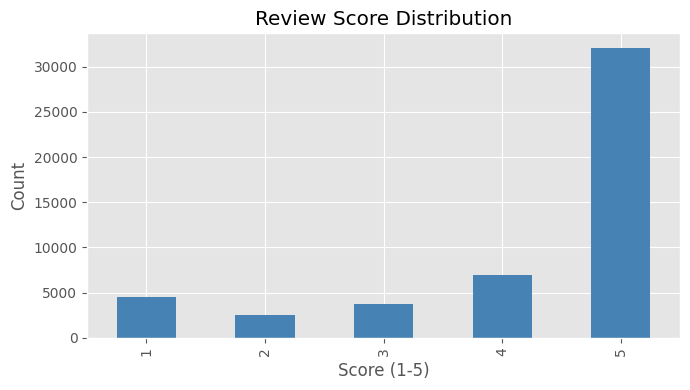

In [5]:
# Check missing values
print("Missing values:\n", df.isnull().sum())
print("\nScore distribution:\n", df['Score'].value_counts())

# Plot score distribution
plt.figure(figsize=(7, 4))
df['Score'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Review Score Distribution')
plt.xlabel('Score (1-5)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Convert scores to sentiment labels
# 1-2 = Negative, 3 = Neutral, 4-5 = Positive
def get_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['Score'].apply(get_sentiment)

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)        # remove HTML
    text = re.sub(r'[^a-z\s]', '', text)    # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

df['clean_text'] = df['Text'].apply(clean_text)

print("Sentiment distribution:\n", df['sentiment'].value_counts())
print("\nSample cleaned text:")
print(df['clean_text'].iloc[0])

Sentiment distribution:
 sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64

Sample cleaned text:
having tried a couple of other brands of glutenfree sandwich cookies these are the best of the bunch theyre crunchy and true to the texture of the other real cookies that arent glutenfree some might think that the filling makes them a bit too sweet but for me that just means ive satisfied my sweet tooth sooner the chocolate version from glutino is just as good and has a true chocolatey taste something that isnt there with the other glutenfree brands out there


In [7]:
# Train/test split
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build pipeline: TF-IDF → Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000,
                               ngram_range=(1, 2),
                               stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000,
                               C=1.0,
                               random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("BASELINE MODEL RESULTS")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

BASELINE MODEL RESULTS
Accuracy : 0.8536
F1 Score : 0.8230

Classification Report:

              precision    recall  f1-score   support

    Negative       0.77      0.55      0.64      1421
     Neutral       0.54      0.08      0.14       758
    Positive       0.87      0.98      0.92      7821

    accuracy                           0.85     10000
   macro avg       0.73      0.54      0.57     10000
weighted avg       0.83      0.85      0.82     10000



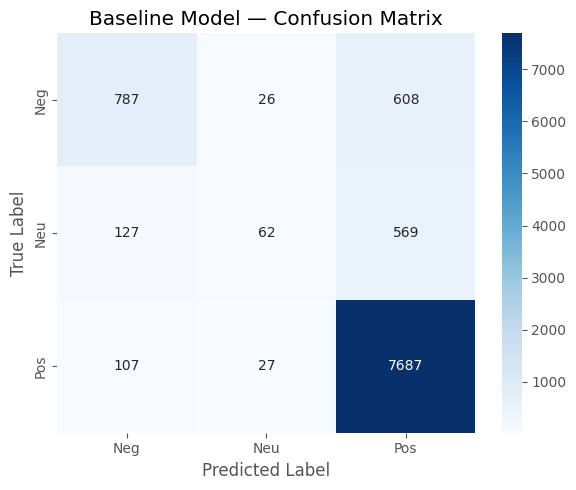

In [8]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred,
                       labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'],
            cmap='Blues')
plt.title('Baseline Model — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [9]:
# Install transformers
import subprocess
subprocess.run(['pip', 'install', 'transformers', 'torch', '-q'])

import torch
from transformers import (AutoTokenizer,
                             AutoModelForSequenceClassification,
                             Trainer, TrainingArguments)
from torch.utils.data import Dataset

print(f"GPU available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

GPU available: True
Using: cuda


In [10]:
# Use smaller subset for DistilBERT (faster training)
label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id2label = {v: k for k, v in label2id.items()}

# Use 8000 samples for fast fine-tuning
df_bert = df.sample(2000, random_state=42).reset_index(drop=True)
df_bert['label'] = df_bert['sentiment'].map(label2id)

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    df_bert['clean_text'].tolist(),
    df_bert['label'].tolist(),
    test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, truncation=True,
                             padding=True, max_length=128,
                             return_tensors='pt')
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[i])
        return item

train_ds = ReviewDataset(X_b_train, y_b_train)
test_ds  = ReviewDataset(X_b_test,  y_b_test)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 1600 | Test: 400


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir='./logs',
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

trainer.train()
print("DistilBERT fine-tuning complete!")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT fine-tuning complete!


Model                     Accuracy       F1
----------------------------------------
TF-IDF + LogReg             0.8536   0.8230
DistilBERT (fine-tuned)     0.7925   0.7451


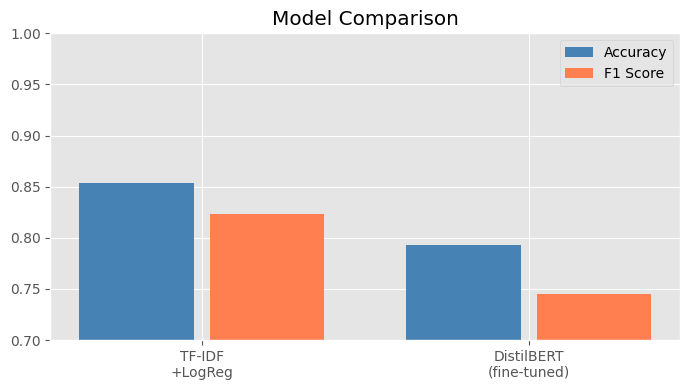

In [12]:
# Evaluate DistilBERT
results = trainer.evaluate()
bert_acc = results['eval_accuracy']
bert_f1  = results['eval_f1']

baseline_acc = accuracy_score(y_test, y_pred)
baseline_f1  = f1_score(y_test, y_pred, average='weighted')

print("="*40)
print(f"{'Model':25} {'Accuracy':>8} {'F1':>8}")
print("-"*40)
print(f"{'TF-IDF + LogReg':25} {baseline_acc:>8.4f} {baseline_f1:>8.4f}")
print(f"{'DistilBERT (fine-tuned)':25} {bert_acc:>8.4f} {bert_f1:>8.4f}")
print("="*40)

# Bar chart comparison
models = ['TF-IDF\n+LogReg', 'DistilBERT\n(fine-tuned)']
accs   = [baseline_acc, bert_acc]
f1s    = [baseline_f1,  bert_f1]

x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, accs, 0.35, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, f1s,  0.35, label='F1 Score',  color='coral')
ax.set_xticks(x); 
ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.0)
ax.legend(); 
ax.set_title('Model Comparison')
plt.tight_layout(); 
plt.show()

In [13]:
# Test on custom reviews
test_reviews = [
    "This product is absolutely amazing! Best purchase ever.",
    "It's okay, nothing special. Does the job I guess.",
    "Terrible quality. Broke after one day. Total waste of money.",
    "Great taste, fast delivery. Will buy again!"
]

# Baseline predictions
print("Baseline Model Predictions")
for review in test_reviews:
    pred = pipeline.predict([clean_text(review)])[0]
    print(f"Review : {review[:60]}...")
    print(f"Prediction: {pred}\n")

# DistilBERT predictions
print("DistilBERT Predictions")
model.eval()
for review in test_reviews:
    enc = tokenizer(review, return_tensors='pt',
                    truncation=True, max_length=128)
    
    # Move inputs to same device as model
    device = next(model.parameters()).device
    enc = {k: v.to(device) for k, v in enc.items()}
    
    with torch.no_grad():
        out = model(**enc)
    pred_id = out.logits.argmax().item()
    print(f"Review : {review[:60]}...")
    print(f"Prediction: {id2label[pred_id]}\n")

Baseline Model Predictions
Review : This product is absolutely amazing! Best purchase ever....
Prediction: Positive

Review : It's okay, nothing special. Does the job I guess....
Prediction: Neutral

Review : Terrible quality. Broke after one day. Total waste of money....
Prediction: Negative

Review : Great taste, fast delivery. Will buy again!...
Prediction: Positive

DistilBERT Predictions
Review : This product is absolutely amazing! Best purchase ever....
Prediction: Positive

Review : It's okay, nothing special. Does the job I guess....
Prediction: Positive

Review : Terrible quality. Broke after one day. Total waste of money....
Prediction: Negative

Review : Great taste, fast delivery. Will buy again!...
Prediction: Positive



In [14]:
import joblib, os

# Save baseline model
joblib.dump(pipeline, 'sentiment_baseline.pkl')

# Save DistilBERT model
os.makedirs('sentiment_bert', exist_ok=True)
model.save_pretrained('sentiment_bert')
tokenizer.save_pretrained('sentiment_bert')

print("Models saved!")
print("sentiment_baseline.pkl  → Baseline model")
print("sentiment_bert/ → DistilBERT model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models saved!
sentiment_baseline.pkl  → Baseline model
sentiment_bert/ → DistilBERT model
